<a href="https://colab.research.google.com/github/Mvdu12/brain_tumor_detection/blob/main/brain_tumor_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
masoudnickparvar_brain_tumor_mri_dataset_path = kagglehub.dataset_download('masoudnickparvar/brain-tumor-mri-dataset')

print('Data source import complete.')


<a href="https://colab.research.google.com/github/Mvdu12/brain_tumor_detection/blob/main/brain_tumor_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Brain Tumor Detection from MRI Scans
## Deep Learning Comparative Study — Custom CNN · VGG16 · ResNet50

| Item | Detail |
|---|---|
| **Task 1** | Binary classification — Tumor (`yes`) vs No Tumor (`no`) |
| **Task 2** | Multi-class — Healthy · Glioma · Meningioma · Pituitary |
| **Framework** | TensorFlow / Keras |
| **Pre-trained weights** | ImageNet (VGG16, ResNet50) |
| **Dataset source (binary)** | [akar49/MRI_Classification](https://huggingface.co/datasets/akar49/MRI_Classification) on Hugging Face (`notumor`/`tumor`, ~3,645 images) |
| **Input size** | Any resolution — `predict_mri_scan()` auto-resizes to what each model expects |


In [ ]:
# =============================================================================
# CELL 1 — Libraries & Reusable Helper Functions
# =============================================================================
# Standard libraries
import os
import random

# Numerical & image processing
import numpy as np
import cv2                        # OpenCV — image reading and contour detection
import imutils                    # Convenience wrappers around OpenCV

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Scikit-learn — splitting and evaluation metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# TensorFlow / Keras — models, layers, training utilities
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16    import VGG16
from tensorflow.keras.applications.vgg16    import preprocess_input as vgg16_preprocess
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet50_preprocess
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


# -----------------------------------------------------------------------------
# HELPER: crop_brain_roi
# Removes the black padding around an MRI scan and returns only the brain region.
# How it works:
#   1. Convert to grayscale and blur to reduce noise.
#   2. Binary-threshold to separate brain (white) from background (black).
#   3. Erode then dilate to clean up small artefacts.
#   4. Find the largest external contour (= the brain).
#   5. Crop tightly to its extreme left/right/top/bottom points.
# If no contour is found (rare edge-case), the original image is returned unchanged.
# -----------------------------------------------------------------------------
def crop_brain_roi(mri_image):
    gray_image   = cv2.cvtColor(mri_image, cv2.COLOR_BGR2GRAY)
    blurred_gray = cv2.GaussianBlur(gray_image, (5, 5), 0)

    # Threshold: pixels > 45 become white (brain), rest black (background)
    binary_mask = cv2.threshold(blurred_gray, 45, 255, cv2.THRESH_BINARY)[1]
    binary_mask = cv2.erode(binary_mask,  None, iterations=2)
    binary_mask = cv2.dilate(binary_mask, None, iterations=2)

    all_contours = cv2.findContours(binary_mask.copy(),
                                    cv2.RETR_EXTERNAL,
                                    cv2.CHAIN_APPROX_SIMPLE)
    all_contours = imutils.grab_contours(all_contours)

    if len(all_contours) == 0:
        return mri_image                        # Nothing to crop — return as-is

    largest_contour = max(all_contours, key=cv2.contourArea)

    # Find the four extreme points of the brain contour
    leftmost_point  = tuple(largest_contour[largest_contour[:, :, 0].argmin()][0])
    rightmost_point = tuple(largest_contour[largest_contour[:, :, 0].argmax()][0])
    topmost_point   = tuple(largest_contour[largest_contour[:, :, 1].argmin()][0])
    bottommost_point= tuple(largest_contour[largest_contour[:, :, 1].argmax()][0])

    # Slice the image to keep only the bounding box of the brain
    cropped_brain = mri_image[
        topmost_point[1]  : bottommost_point[1],
        leftmost_point[0] : rightmost_point[0]
    ]
    return cropped_brain


# -----------------------------------------------------------------------------
# HELPER: plot_accuracy_and_loss
# Draws two side-by-side line charts from a Keras History object:
#   Left  → Training vs Validation Accuracy over epochs
#   Right → Training vs Validation Loss over epochs
# -----------------------------------------------------------------------------
def plot_accuracy_and_loss(training_history, model_name="Model"):
    train_acc   = training_history.history['accuracy']
    val_acc     = training_history.history['val_accuracy']
    train_loss  = training_history.history['loss']
    val_loss    = training_history.history['val_loss']
    epoch_range = range(len(train_acc))

    fig, (ax_acc, ax_loss) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Training History — {model_name}', fontsize=14, fontweight='bold')

    ax_acc.plot(epoch_range, train_acc, label='Train',      linewidth=2)
    ax_acc.plot(epoch_range, val_acc,   label='Validation', linewidth=2, linestyle='--')
    ax_acc.set_title('Accuracy over Epochs')
    ax_acc.set_xlabel('Epoch')
    ax_acc.set_ylabel('Accuracy')
    ax_acc.legend()
    ax_acc.grid(alpha=0.3)

    ax_loss.plot(epoch_range, train_loss, label='Train',      linewidth=2)
    ax_loss.plot(epoch_range, val_loss,   label='Validation', linewidth=2, linestyle='--')
    ax_loss.set_title('Loss over Epochs')
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('Loss Value')
    ax_loss.legend()
    ax_loss.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


# -----------------------------------------------------------------------------
# HELPER: plot_confusion_matrix
# Renders a colour-coded confusion matrix heatmap using seaborn.
# Parameters:
#   true_labels  — ground-truth integer labels
#   pred_labels  — predicted integer labels
#   class_names  — human-readable label list, e.g. ['no', 'yes']
#   chart_title  — string shown as the chart title
#   color_map    — matplotlib colormap name (default 'Blues')
# -----------------------------------------------------------------------------
def plot_confusion_matrix(true_labels, pred_labels, class_names, chart_title, color_map='Blues'):
    confusion_mat = confusion_matrix(true_labels, pred_labels)
    plt.figure(figsize=(7, 5))
    sns.heatmap(confusion_mat, annot=True, fmt='d', cmap=color_map,
                xticklabels=class_names, yticklabels=class_names)
    plt.title(chart_title, fontweight='bold')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()


# -----------------------------------------------------------------------------
# HELPER: predict_mri_scan
# Classifies a single MRI image regardless of its original size or shape —
# the image is resized internally to whatever the given model expects, so
# callers never need to pre-resize anything. Works for both binary models
# (sigmoid, 2 classes) and multi-class models (softmax, 4 classes).
#
# Parameters:
#   image_input  — a file path (str) OR an already-loaded BGR numpy image
#                  (any resolution — this function handles the resize)
#   model        — a trained Keras model
#   target_size  — (width, height) expected by that model, e.g. (224, 224)
#   class_names  — ordered label list matching the model's output,
#                  e.g. ['no', 'yes'] or ['Healthy','Glioma','Meningioma','Pituitary']
#   apply_crop   — whether to run crop_brain_roi() first (True by default —
#                  matches how every model in this notebook was trained)
#
# Returns:
#   predicted_label — string, one of class_names
#   confidence      — float, 0-100
# -----------------------------------------------------------------------------
def predict_mri_scan(image_input, model, target_size, class_names, apply_crop=True):
    if isinstance(image_input, str):
        raw_image = cv2.imread(image_input)
        if raw_image is None:
            raise ValueError(f"Could not read image: {image_input}")
    else:
        raw_image = image_input

    if apply_crop:
        raw_image = crop_brain_roi(raw_image)

    # Resize to whatever this model expects — works no matter the input size
    resized_image  = cv2.resize(raw_image, target_size, interpolation=cv2.INTER_CUBIC)
    normalised_img = resized_image / 255.0
    batch_input    = np.expand_dims(normalised_img, axis=0)

    raw_prediction = model.predict(batch_input, verbose=0)[0]

    if len(class_names) == 2:
        # Binary model — single sigmoid output
        positive_probability = raw_prediction[0]
        predicted_index = int(positive_probability > 0.5)
        confidence = positive_probability * 100 if predicted_index == 1 \
                     else (1 - positive_probability) * 100
    else:
        # Multi-class model — softmax output
        predicted_index = int(np.argmax(raw_prediction))
        confidence = float(raw_prediction[predicted_index]) * 100

    return class_names[predicted_index], confidence


print("✅ All libraries imported and helper functions defined.")


✅ All libraries imported and helper functions defined.


In [ ]:
# =============================================================================
# Download the binary dataset from Hugging Face
# =============================================================================
# Source: https://huggingface.co/datasets/akar49/MRI_Classification
# ~3,645 MRI images labelled "notumor" (0) / "tumor" (1) — a larger
# replacement for the original 253-image yes/no dataset.
!pip install -q datasets

from datasets import load_dataset

hf_dataset = load_dataset("akar49/MRI_Classification")
print(hf_dataset)
print("Label names:", hf_dataset["train"].features["label"].names)


README.md:   0%|          | 0.00/491 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/62.7M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/11.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2934 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/711 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 2934
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 711
    })
})
Label names: ['notumor', 'tumor']


In [ ]:
# =============================================================================
# Duplicate check — avoid train/test leakage
# =============================================================================
# Many brain-tumor MRI datasets on Kaggle/HF trace back to the same original
# source and get re-uploaded under different names. Before combining
# train + test into one pool (this notebook does its own 80/20 split later),
# we use perceptual hashing to drop any test images that are near-duplicates
# of a training image.
!pip install -q imagehash

import imagehash
from PIL import Image as PILImage

def compute_phash(pil_image):
    return imagehash.phash(pil_image)

print("Hashing training images...")
train_hashes = {compute_phash(ex["image"].convert("RGB")): i
                for i, ex in enumerate(hf_dataset["train"])}

print("Checking test images against training hashes...")
duplicate_test_indices = []
for i, ex in enumerate(hf_dataset["test"]):
    h = compute_phash(ex["image"].convert("RGB"))
    if h in train_hashes:
        duplicate_test_indices.append(i)

print(f"Found {len(duplicate_test_indices)} duplicate test images out of {len(hf_dataset['test'])}.")

if duplicate_test_indices:
    keep_indices = [i for i in range(len(hf_dataset["test"])) if i not in duplicate_test_indices]
    hf_dataset["test"] = hf_dataset["test"].select(keep_indices)
    print(f"Removed duplicates. Test set now has {len(hf_dataset['test'])} images.")
else:
    print("No duplicates found — safe to proceed.")


Hashing training images...
Checking test images against training hashes...
Found 423 duplicate test images out of 711.
Removed duplicates. Test set now has 288 images.


In [ ]:
# =============================================================================
# CELL 2 — Load Binary Dataset (Tumor / No Tumor)
# =============================================================================
# Loads images directly from the Hugging Face dataset object (hf_dataset),
# combining train + test splits into one pool — the train/validation split
# used for model training happens later in this notebook (Cell 4).
#
# Label mapping: dataset label 0 = "notumor" -> 0 ("no")
#                 dataset label 1 = "tumor"    -> 1 ("yes")
#
# Steps per image:
#   1. Convert from PIL (RGB) to OpenCV format (BGR).
#   2. Apply crop_brain_roi() to remove black padding.
#   3. Resize to BINARY_IMG_SIZE and normalise pixel values to [0, 1].
# =============================================================================

BINARY_IMG_SIZE = (224, 224)    # Input size expected by VGG16 and ResNet50

BINARY_INT_TO_LABEL = {0: 'no', 1: 'yes'}
BINARY_LABEL_TO_INT = {'no': 0, 'yes': 1}


def load_binary_mri_images(dataset, target_size=BINARY_IMG_SIZE):
    """
    Loads all MRI images from the combined HF dataset (train + test splits),
    applies brain-ROI cropping, resizes, and normalises them.

    Returns:
        image_array  — float32 numpy array of shape (N, H, W, 3)
        label_array  — int numpy array of shape (N,), values 0 or 1
        label_lookup — dict mapping int → class name string
    """
    image_list = []
    label_list = []

    for split_name in ["train", "test"]:
        for example in dataset[split_name]:
            pil_image = example["image"].convert("RGB")
            integer_label = example["label"]           # already 0=notumor, 1=tumor

            raw_image = cv2.cvtColor(np.array(pil_image), cv2.COLOR_RGB2BGR)

            cropped_image  = crop_brain_roi(raw_image)
            resized_image  = cv2.resize(cropped_image, target_size,
                                        interpolation=cv2.INTER_CUBIC)
            normalised_img = resized_image / 255.0      # Scale from [0,255] → [0,1]

            image_list.append(normalised_img)
            label_list.append(integer_label)

    image_array = np.array(image_list)
    label_array = np.array(label_list)

    tumor_count    = int(label_array.sum())
    no_tumor_count = int((label_array == 0).sum())
    print(f"✅ Loaded {len(image_array)} images")
    print(f"   Tumor (yes): {tumor_count}  |  No Tumor (no): {no_tumor_count}")

    return image_array, label_array, BINARY_INT_TO_LABEL


# Run the loader
all_images, all_labels, label_lookup = load_binary_mri_images(hf_dataset)


✅ Loaded 3222 images
   Tumor (yes): 1536  |  No Tumor (no): 1686


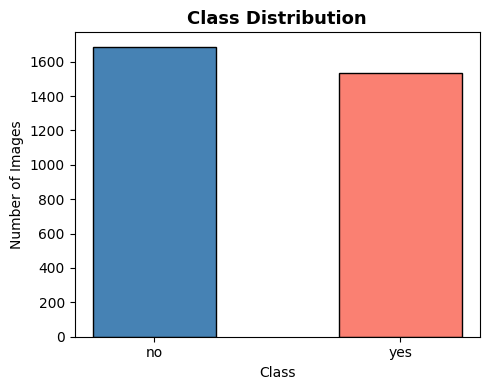

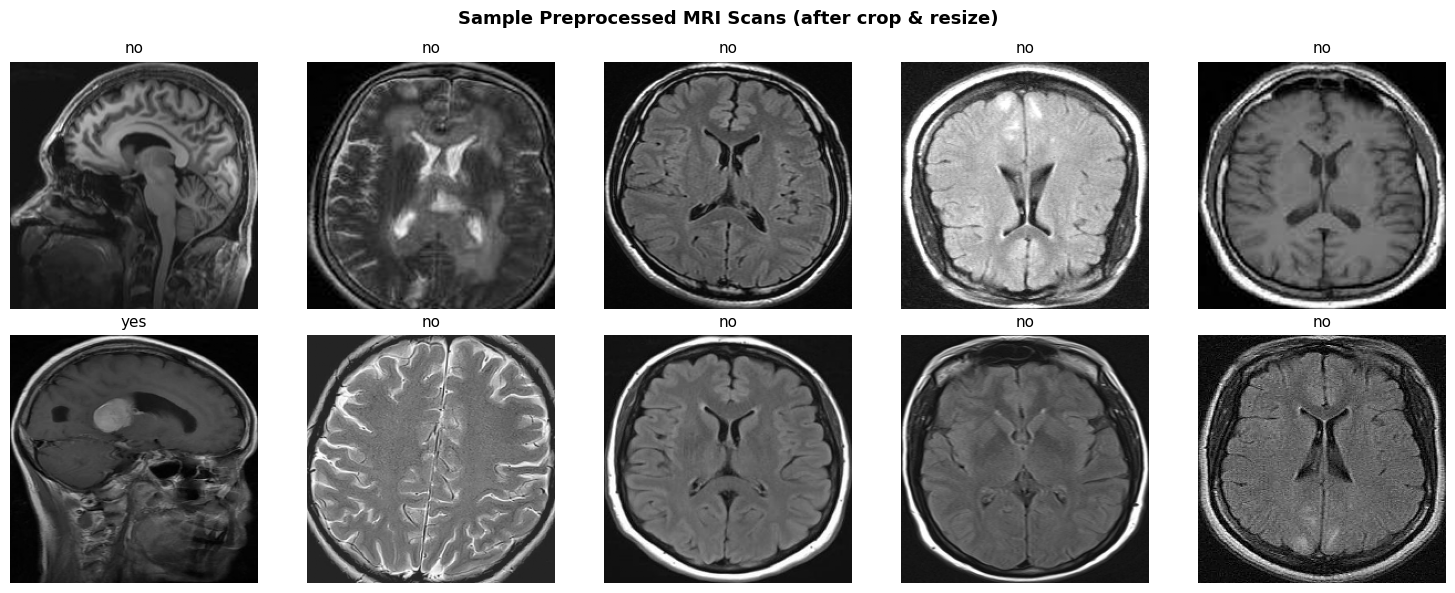

In [ ]:
# =============================================================================
# CELL 3 — Exploratory Data Analysis (EDA)
# =============================================================================
# Before training we visualise:
#   (a) Class distribution — check for class imbalance.
#   (b) A random grid of 10 preprocessed scans — sanity-check the loader.
# =============================================================================

if all_images is not None:

    # ── (a) Class distribution bar chart ─────────────────────────────────────
    unique_classes, class_counts = np.unique(all_labels, return_counts=True)
    bar_colors = ['steelblue', 'salmon']

    plt.figure(figsize=(5, 4))
    plt.bar([label_lookup[cls] for cls in unique_classes],
            class_counts,
            color=bar_colors,
            edgecolor='black',
            width=0.5)
    plt.title('Class Distribution', fontsize=13, fontweight='bold')
    plt.ylabel('Number of Images')
    plt.xlabel('Class')
    plt.tight_layout()
    plt.show()

    # ── (b) Random sample grid ────────────────────────────────────────────────
    # Pick 10 random indices so the grid shows variety rather than the first images
    random_sample_indices = random.sample(range(len(all_images)), 10)

    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    fig.suptitle('Sample Preprocessed MRI Scans (after crop & resize)',
                 fontsize=13, fontweight='bold')

    for axis, sample_idx in zip(axes.flat, random_sample_indices):
        axis.imshow(all_images[sample_idx])
        axis.set_title(label_lookup[all_labels[sample_idx]], fontsize=11)
        axis.axis('off')

    plt.tight_layout()
    plt.show()


In [ ]:
# =============================================================================
# CELL 4 — Train / Validation Split & Data Augmentation Setup
# =============================================================================
# We split 80 % for training and 20 % for validation.
# stratify=y keeps the class ratio identical in both splits.
#
# Data augmentation (applied only to training images during .flow()):
#   - rotation_range=10 : rotate ±10 degrees — MRI scans can be slightly tilted
#   - horizontal_flip   : mirror left↔right — the brain is roughly symmetric
#   - fill_mode='nearest': fill any empty pixels from rotation with the
#                          nearest real pixel value
# NOTE: augmentation does NOT change the stored arrays — it generates new
#       variations on-the-fly inside the training loop.
# =============================================================================

# Before splitting, ensure that all_images and all_labels are not None.
# If they are None, it means the dataset loading in the previous cell failed.
if all_images is None or all_labels is None:
    print("❌ Dataset not loaded. Please ensure the 'Load Binary Dataset' cell above ran successfully.")
else:
    # Split into training and validation sets
    train_images, val_images, train_labels, val_labels = train_test_split(
        all_images, all_labels,
        test_size=0.20,
        random_state=42,      # Fixed seed for reproducibility
        stratify=all_labels   # Maintain class ratio in both splits
    )

    print(f"Training samples  : {len(train_images)}")
    print(f"Validation samples: {len(val_images)}")

    # Augmentation generator — applies random transforms each epoch
    binary_augmentor = ImageDataGenerator(
        rotation_range=10,
        horizontal_flip=True,
        fill_mode='nearest'
    )

    # NOTE: each model below gets its OWN fresh EarlyStopping/ReduceLROnPlateau
    # instances at training time (not a shared list) — reusing one callback
    # across multiple .fit() calls causes it to compare each new model's
    # val_loss against a PREVIOUS model's best value, which can trigger
    # early stopping way too soon and restore badly undertrained weights.

    print("\n✅ Data split and augmentation ready.")



Training samples  : 2577
Validation samples: 645

✅ Data split and augmentation ready.


In [ ]:
# =============================================================================
# CELL 5 — Model A: VGG16 Transfer Learning
# =============================================================================
# Architecture:
#   VGG16 (frozen ImageNet weights)
#     └─ GlobalAveragePooling2D   — reduce spatial dimensions to a 512-d vector
#     └─ Dense(256, relu)         — learn task-specific features
#     └─ BatchNormalization       — stabilise and speed up training
#     └─ Dropout(0.5)             — randomly zero 50 % of units to prevent overfitting
#     └─ Dense(1, sigmoid)        — output probability of "tumor present"
#
# Why freeze VGG16?
#   ImageNet features (edges, textures, shapes) transfer well to medical images.
#   Freezing them lets us train only the small head, which is faster and avoids
#   destroying the pre-trained representations with a large gradient.
# =============================================================================

vgg16_base_model = VGG16(
    weights='imagenet',
    include_top=False,              # Drop the original 1000-class classifier
    input_shape=(224, 224, 3)
)
vgg16_base_model.trainable = False  # Lock all VGG16 weights

vgg16_classifier = models.Sequential([
    vgg16_base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')   # 1 output → binary cross-entropy
], name='VGG16_BrainTumor')

vgg16_classifier.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),  # Low LR — fine-tuning a big base
    loss='binary_crossentropy',
    metrics=['accuracy']
)

vgg16_classifier.summary()


I0000 00:00:1787530650.802913      59 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1787530650.805790      59 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "VGG16_BrainTumor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,297 (56.64 MB)

 Trainable params: 132,097 (516.00 KB)

 Non-trainable params: 14,715,200 (56.13 MB)

🚀 Training VGG16 (Transfer Learning) …
Epoch 1/40
 1/81 ━━━━━━━━━━━━━━━━━━━━ 20:52 16s/step - accuracy: 0.3438 - loss: 1.0381

I0000 00:00:1787530671.979858     175 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


81/81 ━━━━━━━━━━━━━━━━━━━━ 56s 505ms/step - accuracy: 0.7761 - loss: 0.4650 - val_accuracy: 0.9287 - val_loss: 0.5404 - learning_rate: 1.0000e-04
Epoch 2/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 28s 345ms/step - accuracy: 0.8972 - loss: 0.2679 - val_accuracy: 0.9473 - val_loss: 0.4291 - learning_rate: 1.0000e-04
Epoch 3/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 29s 351ms/step - accuracy: 0.9166 - loss: 0.2144 - val_accuracy: 0.9535 - val_loss: 0.3272 - learning_rate: 1.0000e-04
Epoch 4/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 29s 356ms/step - accuracy: 0.9282 - loss: 0.1886 - val_accuracy: 0.9597 - val_loss: 0.2357 - learning_rate: 1.0000e-04
Epoch 5/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 29s 362ms/step - accuracy: 0.9329 - loss: 0.1862 - val_accuracy: 0.9581 - val_loss: 0.1737 - learning_rate: 1.0000e-04
Epoch 6/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 29s 361ms/step - accuracy: 0.9391 - loss: 0.1632 - val_accuracy: 0.9628 - val_loss: 0.1446 - learning_rate: 1.0000e-04
Epoch 7/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 29s 356ms/step - accuracy: 0.94

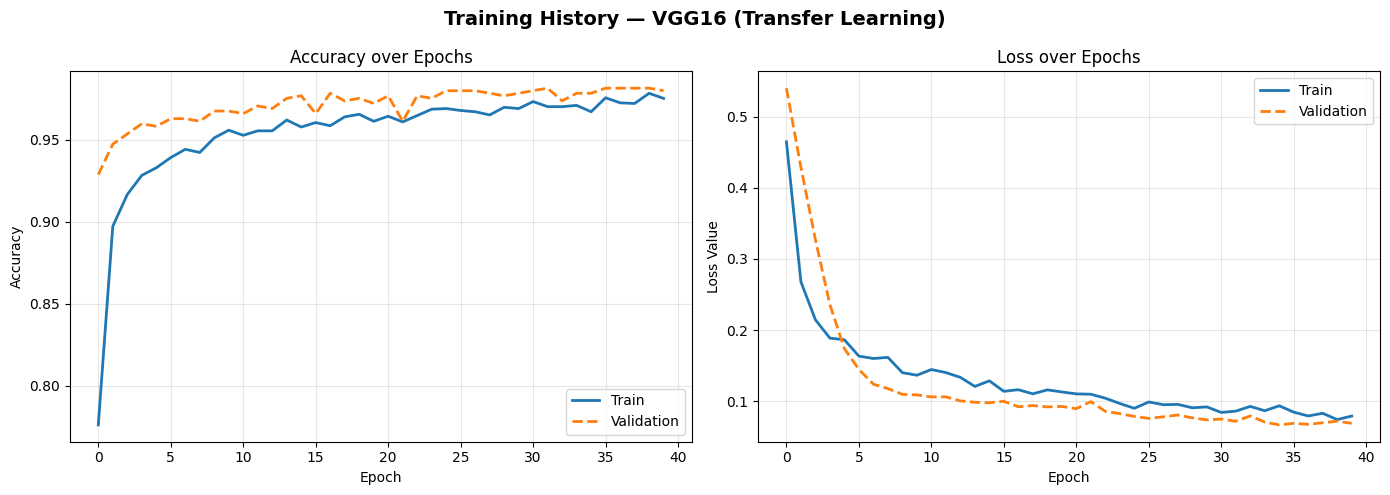

In [ ]:
# =============================================================================
# CELL 6 — Train VGG16
# =============================================================================
# batch_size=32  : standard choice — balances memory and gradient stability
# epochs=40      : EarlyStopping will halt before this if val_loss stops falling
#
# Each model in this notebook gets its OWN fresh callback instances (defined
# right before its .fit() call) rather than a shared list — see the note in
# Cell 4 for why that matters.
# =============================================================================

vgg16_training_callbacks = [
    EarlyStopping(monitor='val_loss', patience=10,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.1,
                     patience=4, min_lr=1e-7, verbose=1)
]

print("🚀 Training VGG16 (Transfer Learning) …")
vgg16_train_history = vgg16_classifier.fit(
    binary_augmentor.flow(train_images, train_labels, batch_size=32),
    validation_data=(val_images, val_labels),
    epochs=40,
    callbacks=vgg16_training_callbacks,
    verbose=1
)

plot_accuracy_and_loss(vgg16_train_history, model_name='VGG16 (Transfer Learning)')


In [ ]:
# =============================================================================
# CELL 7 — Model B: Custom CNN (trained from scratch)
# =============================================================================
# Architecture — three convolutional blocks followed by a classifier head:
#
#   Block 1: Conv2D(32)  → BatchNorm → MaxPool(2×2)
#   Block 2: Conv2D(64)  → BatchNorm → MaxPool(2×2)
#   Block 3: Conv2D(128) → BatchNorm → MaxPool(2×2)
#   Head:    GlobalAveragePooling → Dense(256) → Dropout(0.5) → Dense(1, sigmoid)
# =============================================================================

def build_custom_binary_cnn(input_shape=(224, 224, 3)):
    """
    Constructs a 3-block convolutional neural network for binary MRI classification.
    Args:
        input_shape: (height, width, channels) — default matches VGG16/ResNet50 input.
    Returns:
        Compiled Keras Sequential model.
    """
    cnn_model = models.Sequential([
        # ── Convolutional Block 1: detect low-level features (edges, corners) ──
        layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                      input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # ── Convolutional Block 2: detect mid-level features (textures) ────────
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # ── Convolutional Block 3: detect high-level features (shapes, anatomy) ─
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # ── Classifier Head ────────────────────────────────────────────────────
        layers.GlobalAveragePooling2D(),    # Collapse spatial dims → 1-D feature vector
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),               # Drop 50 % of units to prevent overfitting
        layers.Dense(1, activation='sigmoid')
    ], name='CustomCNN_BrainTumor')

    cnn_model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-4, clipnorm=1.0),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return cnn_model


custom_binary_cnn = build_custom_binary_cnn()
custom_binary_cnn.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CustomCNN_BrainTumor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 127,425 (497.75 KB)

 Trainable params: 126,977 (496.00 KB)

 Non-trainable params: 448 (1.75 KB)

Class weights: {0: np.float64(0.9558605341246291), 1: np.float64(1.048413344182262)}
🚀 Training Custom CNN (from scratch) …
Epoch 1/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 41s 392ms/step - accuracy: 0.8036 - loss: 0.4572 - val_accuracy: 0.4853 - val_loss: 0.6897 - learning_rate: 1.0000e-04
Epoch 2/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 24s 294ms/step - accuracy: 0.8626 - loss: 0.3512 - val_accuracy: 0.5240 - val_loss: 0.7159 - learning_rate: 1.0000e-04
Epoch 3/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 24s 296ms/step - accuracy: 0.8976 - loss: 0.2836 - val_accuracy: 0.5240 - val_loss: 0.8849 - learning_rate: 1.0000e-04
Epoch 4/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 23s 287ms/step - accuracy: 0.9069 - loss: 0.2533 - val_accuracy: 0.5333 - val_loss: 0.7260 - learning_rate: 1.0000e-04
Epoch 5/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 24s 290ms/step - accuracy: 0.9274 - loss: 0.2198 - val_accuracy: 0.8388 - val_loss: 0.4177 - learning_rate: 1.0000e-04
Epoch 6/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 25s 303ms/step - accuracy: 0.9290 - loss: 0.2006 - va

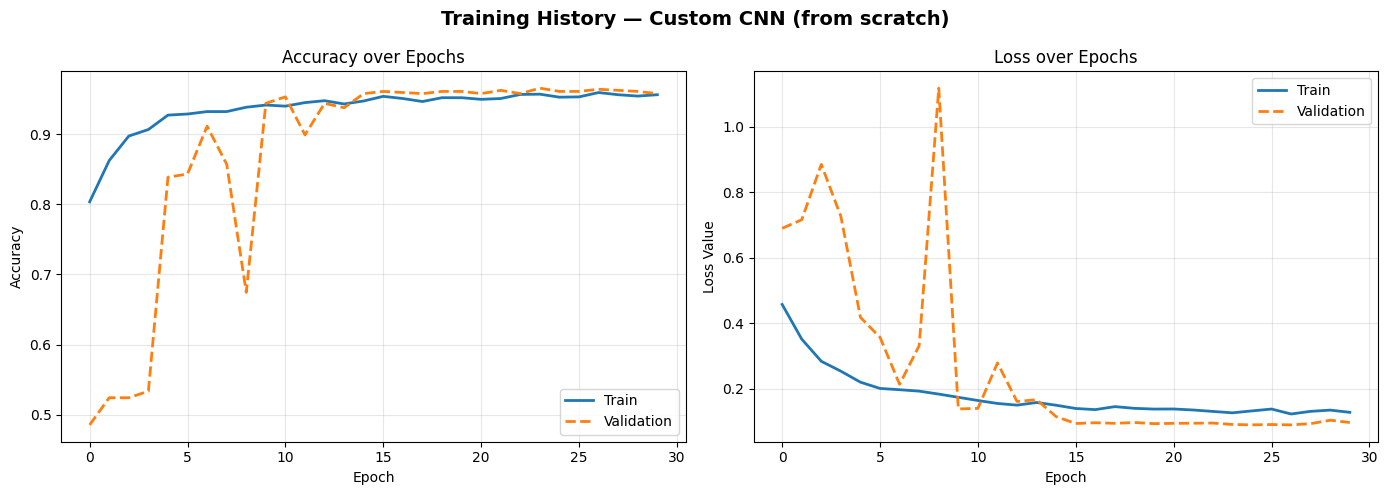

In [ ]:
# =============================================================================
# CELL 8 — Train Custom CNN
# =============================================================================
# class_weight balances the loss contribution of each class regardless of
# how many samples it has — extra insurance on top of the fresh-callbacks
# fix, since this model trains from scratch and benefits most from a
# gentle push toward the minority class if the split isn't perfectly even.
# =============================================================================

from sklearn.utils.class_weight import compute_class_weight

class_weight_values = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weight_dict = dict(enumerate(class_weight_values))
print("Class weights:", class_weight_dict)

custom_cnn_training_callbacks = [
    EarlyStopping(monitor='val_loss', patience=10,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.1,
                     patience=4, min_lr=1e-7, verbose=1)
]

print("🚀 Training Custom CNN (from scratch) …")
custom_cnn_train_history = custom_binary_cnn.fit(
    binary_augmentor.flow(train_images, train_labels, batch_size=32),
    validation_data=(val_images, val_labels),
    epochs=30,
    callbacks=custom_cnn_training_callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

plot_accuracy_and_loss(custom_cnn_train_history, model_name='Custom CNN (from scratch)')


In [ ]:
# =============================================================================
# CELL 9 — Model C: ResNet50 Fine-tuning
# =============================================================================
# Strategy — partial fine-tuning:
#   • All ResNet50 layers EXCEPT the last 10 are frozen.
#   • The last 10 layers (deepest residual blocks) are unfrozen so they can
#     adapt their high-level features to MRI scans specifically.
#   • A very low learning rate (1e-5) prevents destructive updates to the
#     already well-trained lower layers.
#
# The Lambda preprocessing layer reverses our [0,1] normalisation back to
# [0,255] and then applies ResNet50's expected mean-subtraction so the
# pre-trained statistics are still valid.
# =============================================================================

resnet50_base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Unfreeze the model first, then re-freeze everything except the last 10 layers
resnet50_base_model.trainable = True
for individual_layer in resnet50_base_model.layers[:-10]:
    individual_layer.trainable = False

resnet50_classifier = models.Sequential([
    # Undo [0,1] normalisation → apply ResNet50's expected preprocessing
    layers.Lambda(
        lambda pixel_values: resnet50_preprocess(pixel_values * 255.0),
        input_shape=(224, 224, 3)
    ),
    resnet50_base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(1, activation='sigmoid')
], name='ResNet50_BrainTumor')

resnet50_classifier.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),  # Very low LR for fine-tuning
    loss='binary_crossentropy',
    metrics=['accuracy']
)

resnet50_classifier.summary()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "ResNet50_BrainTumor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,112,513 (91.98 MB)

 Trainable params: 4,990,465 (19.04 MB)

 Non-trainable params: 19,122,048 (72.94 MB)

🚀 Training ResNet50 (Fine-tuned) …
Epoch 1/20
162/162 ━━━━━━━━━━━━━━━━━━━━ 57s 258ms/step - accuracy: 0.7454 - loss: 0.5349 - val_accuracy: 0.9426 - val_loss: 0.1799 - learning_rate: 1.0000e-05
Epoch 2/20
162/162 ━━━━━━━━━━━━━━━━━━━━ 26s 160ms/step - accuracy: 0.9336 - loss: 0.1909 - val_accuracy: 0.9659 - val_loss: 0.1029 - learning_rate: 1.0000e-05
Epoch 3/20
162/162 ━━━━━━━━━━━━━━━━━━━━ 26s 159ms/step - accuracy: 0.9569 - loss: 0.1259 - val_accuracy: 0.9674 - val_loss: 0.0812 - learning_rate: 1.0000e-05
Epoch 4/20
162/162 ━━━━━━━━━━━━━━━━━━━━ 26s 162ms/step - accuracy: 0.9647 - loss: 0.1029 - val_accuracy: 0.9721 - val_loss: 0.0683 - learning_rate: 1.0000e-05
Epoch 5/20
162/162 ━━━━━━━━━━━━━━━━━━━━ 26s 160ms/step - accuracy: 0.9713 - loss: 0.0862 - val_accuracy: 0.9783 - val_loss: 0.0599 - learning_rate: 1.0000e-05
Epoch 6/20
162/162 ━━━━━━━━━━━━━━━━━━━━ 26s 160ms/step - accuracy: 0.9779 - loss: 0.0689 - val_accuracy: 0.9752 - val_loss: 0.0568 - learning_rate: 1.0000e-05
Epoch 7/20


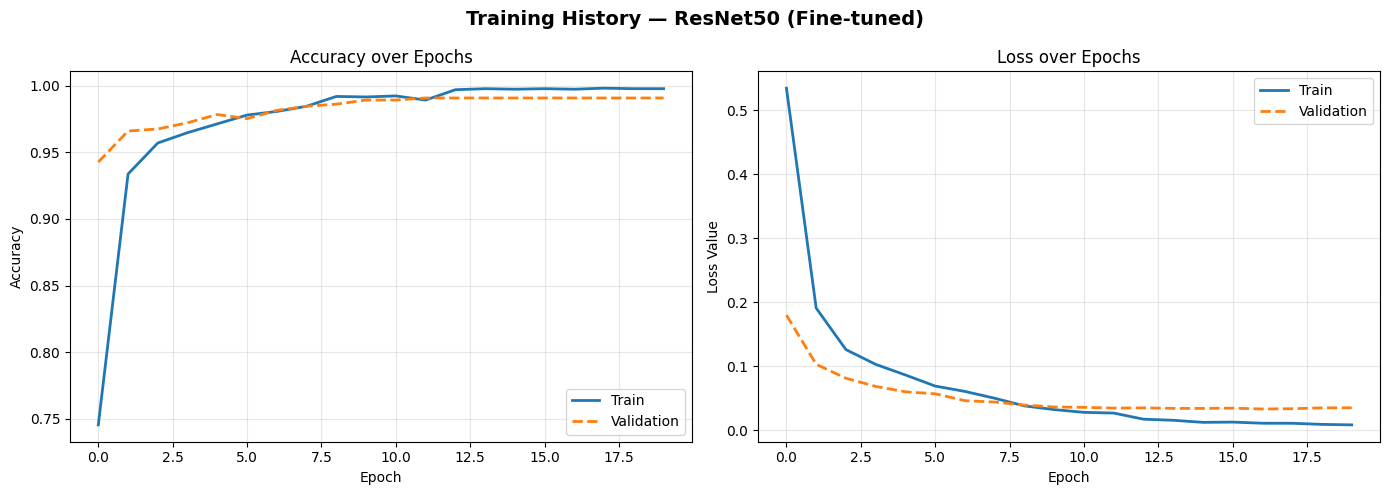

In [ ]:
# =============================================================================
# CELL 10 — Train ResNet50
# =============================================================================
# Smaller batch_size=16 used here because ResNet50 has more parameters and
# consumes more GPU memory per image than VGG16 or the custom CNN.
# =============================================================================

resnet50_training_callbacks = [
    EarlyStopping(monitor='val_loss', patience=10,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.1,
                     patience=4, min_lr=1e-7, verbose=1)
]

print("🚀 Training ResNet50 (Fine-tuned) …")
resnet50_train_history = resnet50_classifier.fit(
    binary_augmentor.flow(train_images, train_labels, batch_size=16),
    validation_data=(val_images, val_labels),
    epochs=20,
    callbacks=resnet50_training_callbacks,
    verbose=1
)

plot_accuracy_and_loss(resnet50_train_history, model_name='ResNet50 (Fine-tuned)')



───────────────────────────────────────────────────────
  VGG16 (Transfer Learning)
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

          no       0.98      0.98      0.98       338
         yes       0.98      0.98      0.98       307

    accuracy                           0.98       645
   macro avg       0.98      0.98      0.98       645
weighted avg       0.98      0.98      0.98       645



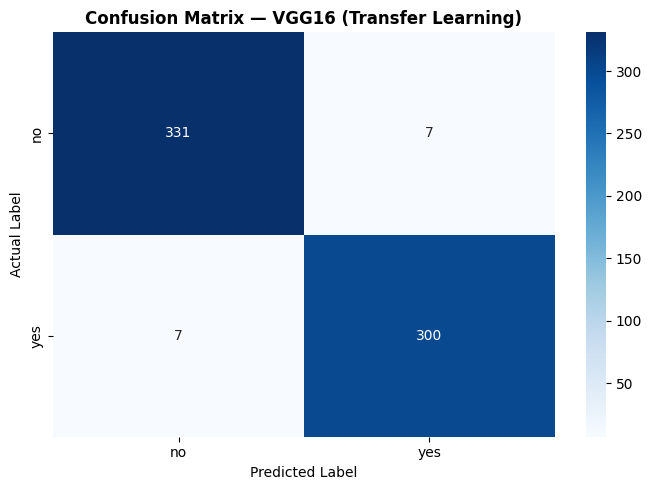


───────────────────────────────────────────────────────
  Custom CNN (from scratch)
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

          no       0.95      0.98      0.97       338
         yes       0.98      0.95      0.96       307

    accuracy                           0.96       645
   macro avg       0.97      0.96      0.96       645
weighted avg       0.96      0.96      0.96       645



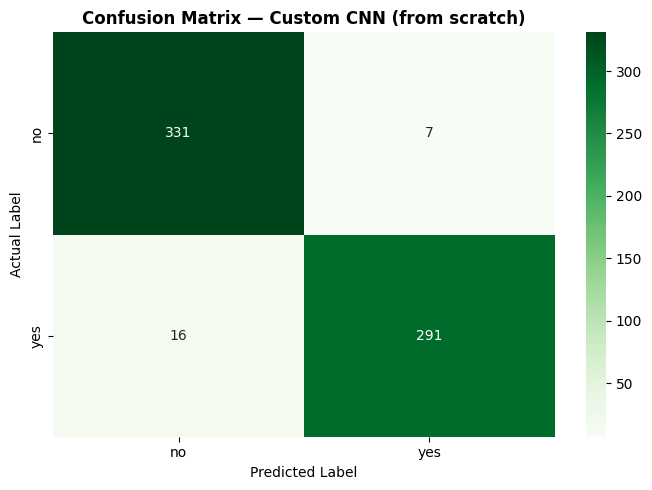


───────────────────────────────────────────────────────
  ResNet50 (Fine-tuned)
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

          no       0.99      0.99      0.99       338
         yes       0.99      0.99      0.99       307

    accuracy                           0.99       645
   macro avg       0.99      0.99      0.99       645
weighted avg       0.99      0.99      0.99       645



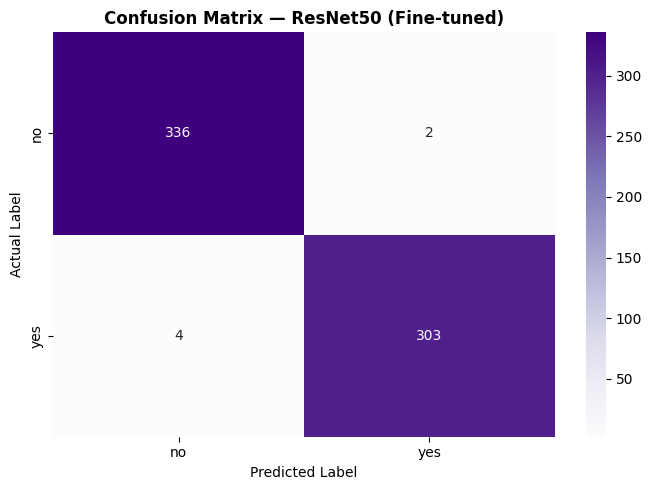

In [ ]:
# =============================================================================
# CELL 11 — Binary Classification: Evaluation of All Three Models
# =============================================================================
# For each model we:
#   1. Run predictions on the held-out validation set.
#   2. Convert raw sigmoid probabilities to class labels (threshold = 0.5).
#   3. Print a full classification report (precision, recall, F1, support).
#   4. Display a confusion matrix heatmap.
# =============================================================================

binary_class_names = list(label_lookup.values())   # ['no', 'yes']

# (model_name, trained_model, confusion_matrix_colormap)
binary_model_registry = [
    ('VGG16 (Transfer Learning)', vgg16_classifier,   'Blues'),
    ('Custom CNN (from scratch)', custom_binary_cnn,  'Greens'),
    ('ResNet50 (Fine-tuned)',      resnet50_classifier,'Purples'),
]

for model_display_name, trained_model, heatmap_color in binary_model_registry:
    # Predict: output is a probability in [0,1]; threshold at 0.5
    raw_probabilities   = trained_model.predict(val_images, verbose=0)
    predicted_int_labels = (raw_probabilities > 0.5).astype('int32').flatten()

    print(f"\n{'─'*55}")
    print(f"  {model_display_name}")
    print(f"{'─'*55}")
    print(classification_report(val_labels, predicted_int_labels,
                                target_names=binary_class_names))

    plot_confusion_matrix(
        true_labels=val_labels,
        pred_labels=predicted_int_labels,
        class_names=binary_class_names,
        chart_title=f'Confusion Matrix — {model_display_name}',
        color_map=heatmap_color
    )


In [ ]:
# =============================================================================
# CELL 12 — Binary Results Summary Table
# =============================================================================
# Aggregates the peak validation accuracy and lowest validation loss for each
# model into a single pandas DataFrame sorted best → worst.
# =============================================================================

binary_results_dict = {
    'Model': [
        'VGG16 (Transfer Learning)',
        'Custom CNN (from scratch)',
        'ResNet50 (Fine-tuned)'
    ],
    'Best Validation Accuracy (%)': [
        round(max(vgg16_train_history.history['val_accuracy'])     * 100, 2),
        round(max(custom_cnn_train_history.history['val_accuracy'])* 100, 2),
        round(max(resnet50_train_history.history['val_accuracy'])  * 100, 2),
    ],
    'Best Validation Loss': [
        round(min(vgg16_train_history.history['val_loss']),     4),
        round(min(custom_cnn_train_history.history['val_loss']),4),
        round(min(resnet50_train_history.history['val_loss']),  4),
    ]
}

binary_results_df = pd.DataFrame(binary_results_dict)
binary_results_df = binary_results_df.sort_values('Best Validation Accuracy (%)',
                                                   ascending=False)

print("🏆 Binary Classification — Final Comparison")
display(binary_results_df.reset_index(drop=True))


🏆 Binary Classification — Final Comparison


,Model,Best Validation Accuracy (%),Best Validation Loss
0,ResNet50 (Fine-tuned),99.07,0.0330
1,VGG16 (Transfer Learning),98.14,0.0664
2,Custom CNN (from scratch),96.59,0.0893


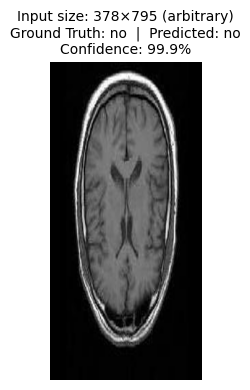

In [ ]:
# =============================================================================
# CELL 13 — Single-Image Prediction Demo (Binary — ResNet50)
# =============================================================================
# Demonstrates that predict_mri_scan() works on an MRI image of ANY size —
# the source image below is resized to a random resolution first (simulating
# an arbitrary uploaded photo), then classified without any manual resizing.
# =============================================================================

demo_index      = random.randint(0, len(hf_dataset["test"]) - 1)
demo_example    = hf_dataset["test"][demo_index]
demo_pil_image  = demo_example["image"].convert("RGB")
ground_truth    = BINARY_INT_TO_LABEL[demo_example["label"]]

# Simulate an arbitrarily-sized uploaded photo (NOT pre-resized to 224x224)
random_demo_size = (random.randint(180, 900), random.randint(180, 900))
demo_pil_resized = demo_pil_image.resize(random_demo_size)
demo_bgr_image   = cv2.cvtColor(np.array(demo_pil_resized), cv2.COLOR_RGB2BGR)

predicted_class, prediction_confidence = predict_mri_scan(
    demo_bgr_image, resnet50_classifier,
    target_size=BINARY_IMG_SIZE,
    class_names=['no', 'yes'],
    apply_crop=True
)

plt.figure(figsize=(4, 4))
plt.imshow(cv2.cvtColor(demo_bgr_image, cv2.COLOR_BGR2RGB))
plt.title(
    f"Input size: {random_demo_size[0]}×{random_demo_size[1]} (arbitrary)\n"
    f"Ground Truth: {ground_truth}  |  Predicted: {predicted_class}\n"
    f"Confidence: {prediction_confidence:.1f}%",
    fontsize=10
)
plt.axis('off')
plt.tight_layout()
plt.show()


---
## Part 2 — Multi-Class Classification
### 4 Classes: Healthy · Glioma · Meningioma · Pituitary

**Dataset structure expected:**
```
brain-tumor-mri-dataset/
├── Training/
│   ├── notumor/
│   ├── glioma/
│   ├── meningioma/
│   └── pituitary/
└── Testing/
    ├── notumor/
    ├── glioma/
    ├── meningioma/
    └── pituitary/
```

**Pipeline notes (matches the binary section's methodology):**
- Classes are balanced dynamically to the smallest available class, instead of a fixed cap — uses as much data as possible.
- `crop_brain_roi()` is applied to every image, same as the binary pipeline.
- Training uses the same rotation/flip data augmentation as the binary section.
- ResNet50 is partially fine-tuned (last 10 layers unfrozen), matching the binary ResNet50 strategy.
- All models classify MRI images of **any input resolution** — see `predict_mri_scan()` in Cell 1.


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset


In [ ]:
# =============================================================================
# CELL 14 — Load Multi-Class Dataset (4 tumour types)
# =============================================================================
# The multi-class dataset uses a different folder structure: it has separate
# Training/ and Testing/ directories, each containing 4 class sub-folders.
# We merge both splits into a single pool and re-split with stratification.
#
# Classes are balanced to the size of the SMALLEST available class (found by
# scanning the folders first) instead of a fixed hardcoded cap — this uses as
# much of the dataset as possible while keeping classes balanced.
#
# crop_brain_roi() is applied here too, matching the binary pipeline, so both
# tasks use the same preprocessing methodology.
# =============================================================================

MULTICLASS_IMG_SIZE = (128, 128)   # Smaller than 224 — reduces memory for 4-class task


def locate_multiclass_dataset():
    """
    Auto-discovers the multi-class dataset folder (the one containing both
    a Training/ and Testing/ sub-folder), same approach as the binary loader.
    Handles Kaggle sometimes nesting the dataset one extra folder deep.
    """
    candidate_paths = [
        '/kaggle/input/brain-tumor-mri-dataset',
        '/kaggle/input/brain-tumor-mri-dataset/brain-tumor-mri-dataset',
        '/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset',
    ]
    for candidate in candidate_paths:
        if os.path.exists(os.path.join(candidate, 'Training')) and \
           os.path.exists(os.path.join(candidate, 'Testing')):
            print(f"✅ Multi-class dataset found at: {candidate}")
            return candidate

    # Fallback: recursive search under /kaggle/input
    for folder_root, sub_dirs, _ in os.walk('/kaggle/input'):
        if 'Training' in sub_dirs and 'Testing' in sub_dirs:
            print(f"✅ Multi-class dataset found at: {folder_root}")
            return folder_root

    print("❌ Could not find the multi-class dataset.")
    print("   Make sure the 'Brain Tumor MRI Dataset' (masoudnickparvar) is attached")
    print("   under Add Data, and that it contains Training/ and Testing/ folders.")
    return None


MULTICLASS_DATASET_PATH = locate_multiclass_dataset()

# Integer labels for the four classes
MULTICLASS_LABEL_MAP   = {'notumor': 0, 'glioma': 1, 'meningioma': 2, 'pituitary': 3}
MULTICLASS_CLASS_NAMES = ['Healthy', 'Glioma', 'Meningioma', 'Pituitary']


def count_available_images(dataset_root):
    """Counts how many valid image files exist per class across Training+Testing."""
    counts = {class_name: 0 for class_name in MULTICLASS_LABEL_MAP}
    for dataset_split in ['Training', 'Testing']:
        split_folder = os.path.join(dataset_root, dataset_split)
        if not os.path.exists(split_folder):
            continue
        for class_folder_name in MULTICLASS_LABEL_MAP:
            class_folder_path = os.path.join(split_folder, class_folder_name)
            if not os.path.exists(class_folder_path):
                continue
            valid_files = [f for f in os.listdir(class_folder_path)
                            if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            counts[class_folder_name] += len(valid_files)
    return counts


def load_multiclass_mri_images(dataset_root, target_size=MULTICLASS_IMG_SIZE):
    """
    Loads MRI images for 4-class brain tumour classification.

    Scans both Training/ and Testing/ sub-directories, applies crop_brain_roi()
    to remove black padding (same as the binary pipeline), resizes, and
    normalises. Every class is capped at the size of the smallest available
    class so the final dataset stays balanced without discarding more data
    than necessary.

    Returns:
        image_array — float32 numpy array (N, H, W, 3), pixel values in [0,1]
        label_array — int numpy array (N,), values 0-3
    """
    available_counts = count_available_images(dataset_root)
    per_class_limit = min(available_counts.values()) if available_counts else 0
    print("Available images per class:", available_counts)
    print(f"Balancing every class to {per_class_limit} images (smallest available class).")

    image_list = []
    label_list = []
    loaded_per_class = {class_name: 0 for class_name in MULTICLASS_LABEL_MAP}

    for dataset_split in ['Training', 'Testing']:
        split_folder = os.path.join(dataset_root, dataset_split)

        if not os.path.exists(split_folder):
            print(f"⚠️  Folder not found: {split_folder} — skipping.")
            continue

        for class_folder_name, integer_label in MULTICLASS_LABEL_MAP.items():
            if loaded_per_class[class_folder_name] >= per_class_limit:
                continue

            class_folder_path = os.path.join(split_folder, class_folder_name)
            if not os.path.exists(class_folder_path):
                continue

            valid_files = [f for f in os.listdir(class_folder_path)
                            if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

            for image_filename in valid_files:
                if loaded_per_class[class_folder_name] >= per_class_limit:
                    break

                raw_img = cv2.imread(os.path.join(class_folder_path, image_filename))
                if raw_img is None:
                    continue

                cropped_img    = crop_brain_roi(raw_img)
                resized_img    = cv2.resize(cropped_img, target_size,
                                            interpolation=cv2.INTER_CUBIC)
                normalised_img = (resized_img / 255.0).astype(np.float32)

                image_list.append(normalised_img)
                label_list.append(integer_label)
                loaded_per_class[class_folder_name] += 1

    multiclass_images = np.array(image_list)
    multiclass_labels = np.array(label_list)

    # Print per-class counts so we can verify balance
    unique_cls, cls_counts = np.unique(multiclass_labels, return_counts=True)
    for cls_idx, count in zip(unique_cls, cls_counts):
        print(f"  {MULTICLASS_CLASS_NAMES[cls_idx]:12s}: {count} images")
    print(f"  Total: {len(multiclass_images)}")

    return multiclass_images, multiclass_labels


if MULTICLASS_DATASET_PATH is None:
    raise RuntimeError("Multi-class dataset not found — see the message above for what to check.")

print("⏳ Loading multi-class MRI dataset …")
multiclass_images, multiclass_labels = load_multiclass_mri_images(MULTICLASS_DATASET_PATH)

# Stratified split so each class is proportionally represented in both sets
mc_train_images, mc_val_images, mc_train_labels, mc_val_labels = train_test_split(
    multiclass_images, multiclass_labels,
    test_size=0.20,
    random_state=42,
    stratify=multiclass_labels
)

print(f"\n✅ Multi-class split — Train: {len(mc_train_images)}  |  Validation: {len(mc_val_images)}")


✅ Multi-class dataset found at: /kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset
⏳ Loading multi-class MRI dataset …
Available images per class: {'notumor': 1800, 'glioma': 1800, 'meningioma': 1800, 'pituitary': 1800}
Balancing every class to 1800 images (smallest available class).
  Healthy     : 1800 images
  Glioma      : 1800 images
  Meningioma  : 1800 images
  Pituitary   : 1800 images
  Total: 7200

✅ Multi-class split — Train: 5760  |  Validation: 1440


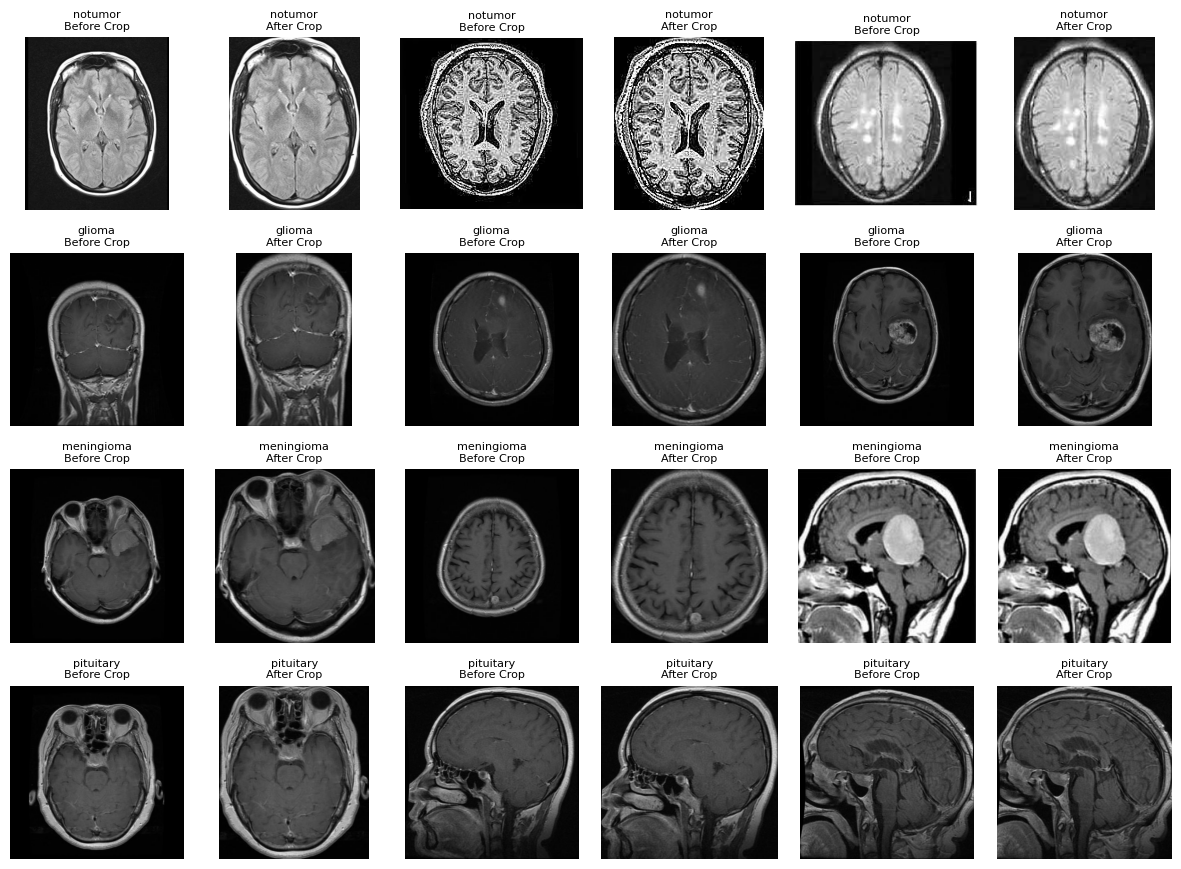

If the 'After Crop' images still clearly show the full brain, crop_brain_roi()
is safe to use for multi-class training — no changes needed.

If cropping looks wrong for this dataset, disable it by changing this line
inside load_multiclass_mri_images() (in the dataset-loading cell above):
    cropped_img = crop_brain_roi(raw_img)
to:
    cropped_img = raw_img


In [ ]:
# =============================================================================
# SANITY CHECK — Preview crop_brain_roi() on Multi-Class Samples
# =============================================================================
# Run this BEFORE training the multi-class models. crop_brain_roi() was
# originally tuned for the binary dataset — this cell shows a few samples
# from each of the 4 classes, before and after cropping, so you can confirm
# it isn't cutting off important parts of the scan before you commit to a
# full training run.
#
# If the "After Crop" images look wrong (cut off, mostly black, or missing
# the brain), skip applying crop_brain_roi() for the multi-class section —
# see the note at the bottom of this cell for how to disable it.
# =============================================================================

if MULTICLASS_DATASET_PATH is None:
    print("❌ MULTICLASS_DATASET_PATH is not set — run the dataset-loading cell first.")
else:
    samples_per_class = 3
    fig, axes = plt.subplots(len(MULTICLASS_LABEL_MAP), samples_per_class * 2,
                              figsize=(samples_per_class * 4, len(MULTICLASS_LABEL_MAP) * 2.2))

    for row_idx, class_folder_name in enumerate(MULTICLASS_LABEL_MAP):
        # Prefer the Training split; fall back to Testing if needed
        class_folder_path = None
        for dataset_split in ['Training', 'Testing']:
            candidate = os.path.join(MULTICLASS_DATASET_PATH, dataset_split, class_folder_name)
            if os.path.exists(candidate):
                class_folder_path = candidate
                break

        if class_folder_path is None:
            print(f"⚠️  Could not find folder for class: {class_folder_name}")
            continue

        valid_files = [f for f in os.listdir(class_folder_path)
                        if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        sample_files = random.sample(valid_files, min(samples_per_class, len(valid_files)))

        for col_idx, image_filename in enumerate(sample_files):
            raw_img     = cv2.imread(os.path.join(class_folder_path, image_filename))
            cropped_img = crop_brain_roi(raw_img)

            ax_before = axes[row_idx, col_idx * 2]
            ax_before.imshow(cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB))
            ax_before.set_title(f"{class_folder_name}\nBefore Crop", fontsize=8)
            ax_before.axis('off')

            ax_after = axes[row_idx, col_idx * 2 + 1]
            ax_after.imshow(cv2.cvtColor(cropped_img, cv2.COLOR_BGR2RGB))
            ax_after.set_title(f"{class_folder_name}\nAfter Crop", fontsize=8)
            ax_after.axis('off')

    plt.tight_layout()
    plt.show()

    print("If the 'After Crop' images still clearly show the full brain, crop_brain_roi()")
    print("is safe to use for multi-class training — no changes needed.")
    print()
    print("If cropping looks wrong for this dataset, disable it by changing this line")
    print("inside load_multiclass_mri_images() (in the dataset-loading cell above):")
    print("    cropped_img = crop_brain_roi(raw_img)")
    print("to:")
    print("    cropped_img = raw_img")


In [ ]:
# =============================================================================
# CELL 15 — Build & Train All Three Multi-Class Models
# =============================================================================
# All models output a 4-neuron softmax layer and use
# sparse_categorical_crossentropy loss (labels are plain integers, not one-hot).
#
# Each model gets its OWN fresh EarlyStopping/ReduceLROnPlateau instances —
# reusing one shared callback list across multiple .fit() calls causes it to
# compare each new model's val_loss against a PREVIOUS model's best value,
# which can trigger early stopping too soon and restore badly undertrained
# weights (this broke VGG16 in an earlier run of this notebook).
#
# Data augmentation (rotation + horizontal flip) mirrors the binary section to
# reduce overfitting — especially useful for the Custom CNN, which trains
# from scratch.
# =============================================================================

multiclass_augmentor = ImageDataGenerator(
    rotation_range=10,
    horizontal_flip=True,
    fill_mode='nearest'
)

# ──────────────────────────────────────────────────────────────────────────────
# A. Custom CNN — trained from scratch on 128×128 images
# ──────────────────────────────────────────────────────────────────────────────
mc_custom_cnn = models.Sequential([
    # Block 1 — low-level feature detection
    layers.Conv2D(32,  (3,3), activation='relu', padding='same',
                  input_shape=(128, 128, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    # Block 2 — mid-level feature detection
    layers.Conv2D(64,  (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    # Block 3 — high-level feature detection
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    # Classifier head
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(4, activation='softmax')   # 4 classes
], name='MC_CustomCNN')

mc_custom_cnn.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

mc_custom_cnn_callbacks = [
    EarlyStopping(monitor='val_loss', patience=8,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2,
                     patience=3, min_lr=1e-7, verbose=1)
]

print("🚀 Training Multi-class Custom CNN …")
mc_custom_cnn_history = mc_custom_cnn.fit(
    multiclass_augmentor.flow(mc_train_images, mc_train_labels, batch_size=32),
    validation_data=(mc_val_images, mc_val_labels),
    epochs=20, callbacks=mc_custom_cnn_callbacks, verbose=1
)

# ──────────────────────────────────────────────────────────────────────────────
# B. ResNet50 — partial fine-tuning (last 10 layers unfrozen)
# ──────────────────────────────────────────────────────────────────────────────
# Same strategy as the binary section: freeze everything except the last 10
# layers so the model can adapt its high-level features to MRI scans, with a
# low learning rate to avoid destroying the pre-trained weights. The Lambda
# layer reverses our [0,1] normalisation and re-applies ResNet50's expected
# preprocessing, matching the binary ResNet50 model exactly.
# ──────────────────────────────────────────────────────────────────────────────
resnet50_mc_base = ResNet50(weights='imagenet', include_top=False,
                             input_shape=(128, 128, 3))
resnet50_mc_base.trainable = True
for individual_layer in resnet50_mc_base.layers[:-10]:
    individual_layer.trainable = False

mc_resnet50 = models.Sequential([
    layers.Lambda(
        lambda pixel_values: resnet50_preprocess(pixel_values * 255.0),
        input_shape=(128, 128, 3)
    ),
    resnet50_mc_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(4, activation='softmax')
], name='MC_ResNet50')

mc_resnet50.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),   # low LR — fine-tuning, not training from scratch
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

mc_resnet50_callbacks = [
    EarlyStopping(monitor='val_loss', patience=8,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2,
                     patience=3, min_lr=1e-7, verbose=1)
]

print("\n🚀 Training Multi-class ResNet50 (Fine-tuned) …")
mc_resnet50_history = mc_resnet50.fit(
    multiclass_augmentor.flow(mc_train_images, mc_train_labels, batch_size=16),
    validation_data=(mc_val_images, mc_val_labels),
    epochs=20, callbacks=mc_resnet50_callbacks, verbose=1
)

# ──────────────────────────────────────────────────────────────────────────────
# C. VGG16 — frozen base (feature extractor only)
# ──────────────────────────────────────────────────────────────────────────────
vgg16_mc_base = VGG16(weights='imagenet', include_top=False,
                       input_shape=(128, 128, 3))
vgg16_mc_base.trainable = False

mc_vgg16 = models.Sequential([
    vgg16_mc_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(4, activation='softmax')
], name='MC_VGG16')

mc_vgg16.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

mc_vgg16_callbacks = [
    EarlyStopping(monitor='val_loss', patience=8,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2,
                     patience=3, min_lr=1e-7, verbose=1)
]

print("\n🚀 Training Multi-class VGG16 …")
mc_vgg16_history = mc_vgg16.fit(
    multiclass_augmentor.flow(mc_train_images, mc_train_labels, batch_size=32),
    validation_data=(mc_val_images, mc_val_labels),
    epochs=20, callbacks=mc_vgg16_callbacks, verbose=1
)

print("\n✅ All multi-class models finished training.")


🚀 Training Multi-class Custom CNN …


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 28s 118ms/step - accuracy: 0.5455 - loss: 1.0716 - val_accuracy: 0.2535 - val_loss: 1.4064 - learning_rate: 1.0000e-04
Epoch 2/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 20s 110ms/step - accuracy: 0.6413 - loss: 0.8887 - val_accuracy: 0.3354 - val_loss: 1.4336 - learning_rate: 1.0000e-04
Epoch 3/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 20s 110ms/step - accuracy: 0.7009 - loss: 0.7625 - val_accuracy: 0.4708 - val_loss: 1.7878 - learning_rate: 1.0000e-04
Epoch 4/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.7287 - loss: 0.6899
Epoch 4: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.
180/180 ━━━━━━━━━━━━━━━━━━━━ 20s 110ms/step - accuracy: 0.7486 - loss: 0.6625 - val_accuracy: 0.4868 - val_loss: 1.6683 - learning_rate: 1.0000e-04
Epoch 5/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 20s 109ms/step - accuracy: 0.7757 - loss: 0.6037 - val_accuracy: 0.6056 - val_loss: 0.9958 - learning_rate: 2.0000e-05
Epoch 6/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 20s 112ms/s

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


360/360 ━━━━━━━━━━━━━━━━━━━━ 42s 78ms/step - accuracy: 0.5554 - loss: 1.0938 - val_accuracy: 0.7979 - val_loss: 0.5704 - learning_rate: 1.0000e-05
Epoch 2/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 22s 60ms/step - accuracy: 0.7583 - loss: 0.6369 - val_accuracy: 0.8271 - val_loss: 0.4565 - learning_rate: 1.0000e-05
Epoch 3/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 22s 60ms/step - accuracy: 0.8090 - loss: 0.5003 - val_accuracy: 0.8493 - val_loss: 0.3916 - learning_rate: 1.0000e-05
Epoch 4/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 22s 60ms/step - accuracy: 0.8387 - loss: 0.4193 - val_accuracy: 0.8792 - val_loss: 0.3170 - learning_rate: 1.0000e-05
Epoch 5/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 22s 61ms/step - accuracy: 0.8693 - loss: 0.3474 - val_accuracy: 0.8938 - val_loss: 0.2957 - learning_rate: 1.0000e-05
Epoch 6/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 22s 60ms/step - accuracy: 0.8833 - loss: 0.3116 - val_accuracy: 0.9049 - val_loss: 0.2748 - learning_rate: 1.0000e-05
Epoch 7/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 22s 60ms/step - accurac

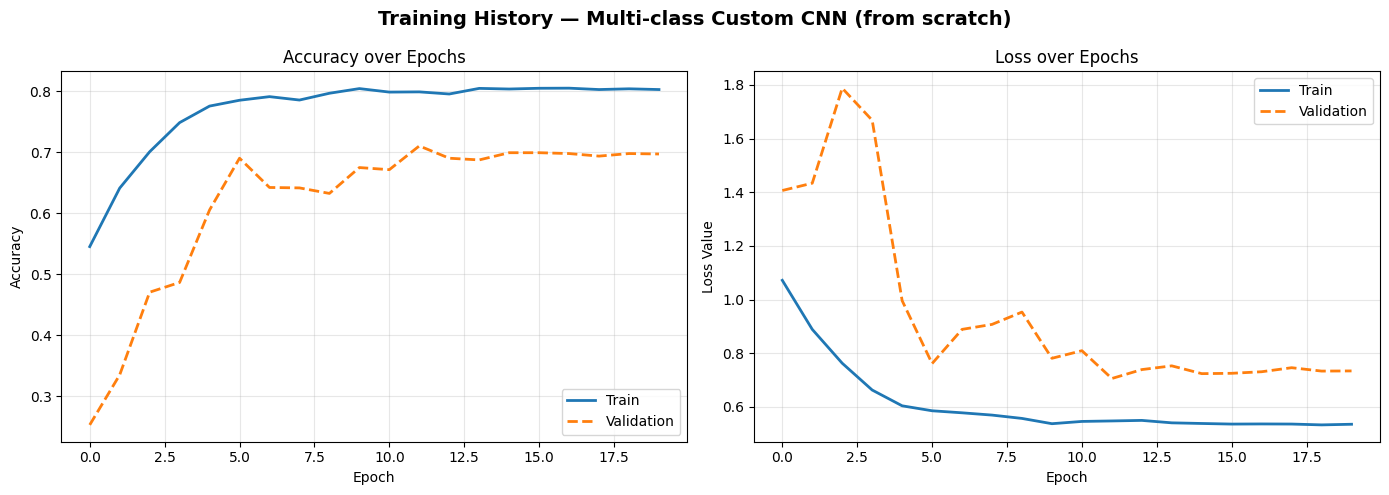


────────────────────────────────────────────────────────────
  Custom CNN (from scratch)
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

     Healthy       0.88      0.94      0.91       360
      Glioma       0.76      0.73      0.75       360
  Meningioma       0.83      0.20      0.32       360
   Pituitary       0.56      0.98      0.71       360

    accuracy                           0.71      1440
   macro avg       0.76      0.71      0.67      1440
weighted avg       0.76      0.71      0.67      1440



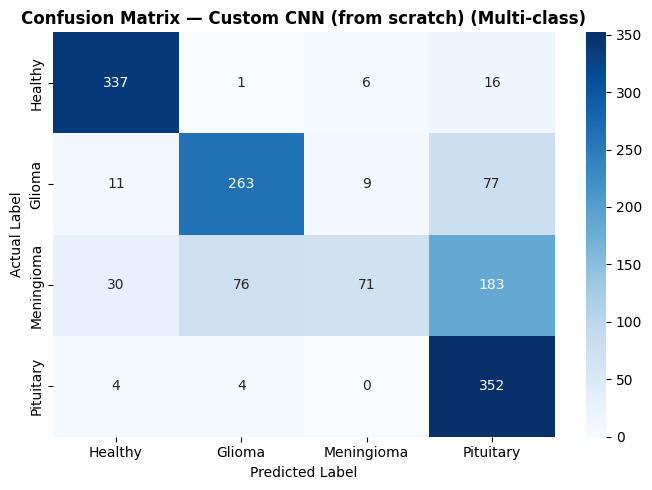

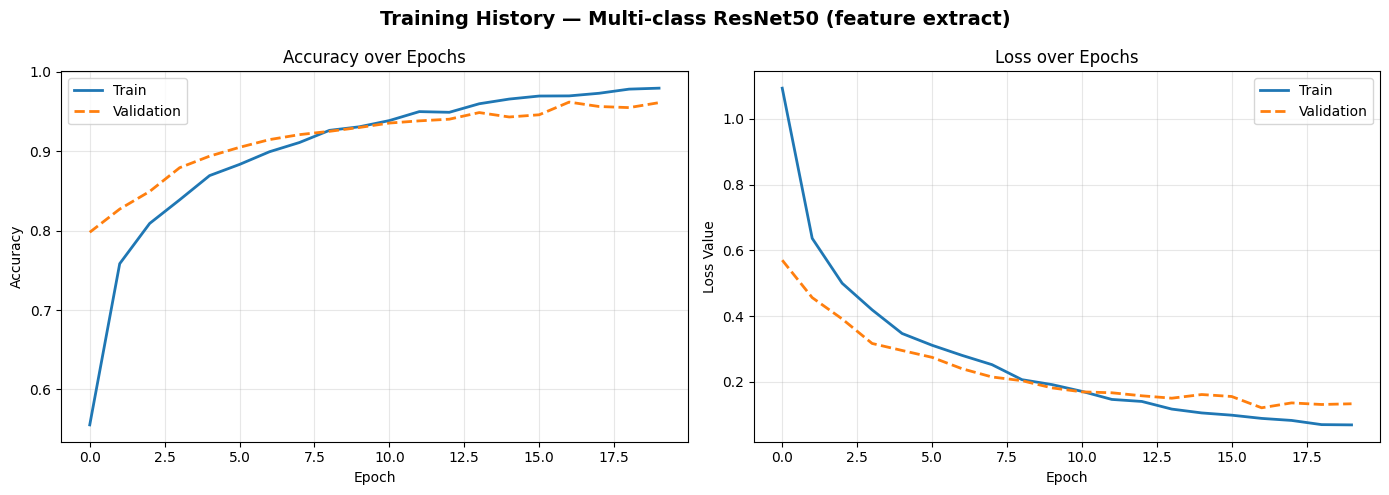


────────────────────────────────────────────────────────────
  ResNet50 (feature extract)
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

     Healthy       0.99      0.99      0.99       360
      Glioma       0.97      0.93      0.95       360
  Meningioma       0.94      0.94      0.94       360
   Pituitary       0.95      0.99      0.97       360

    accuracy                           0.96      1440
   macro avg       0.96      0.96      0.96      1440
weighted avg       0.96      0.96      0.96      1440



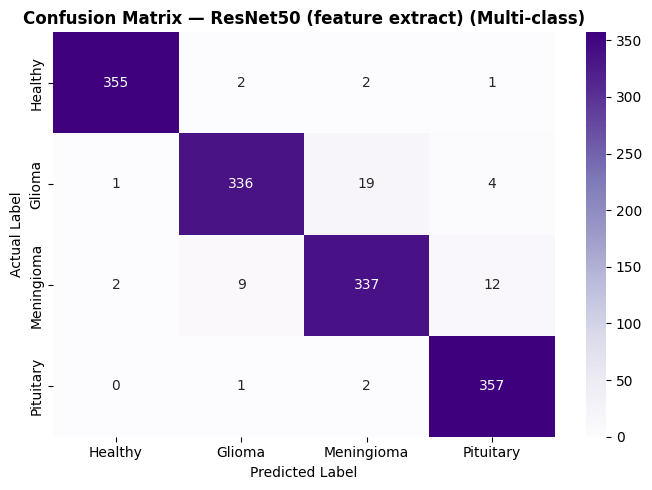

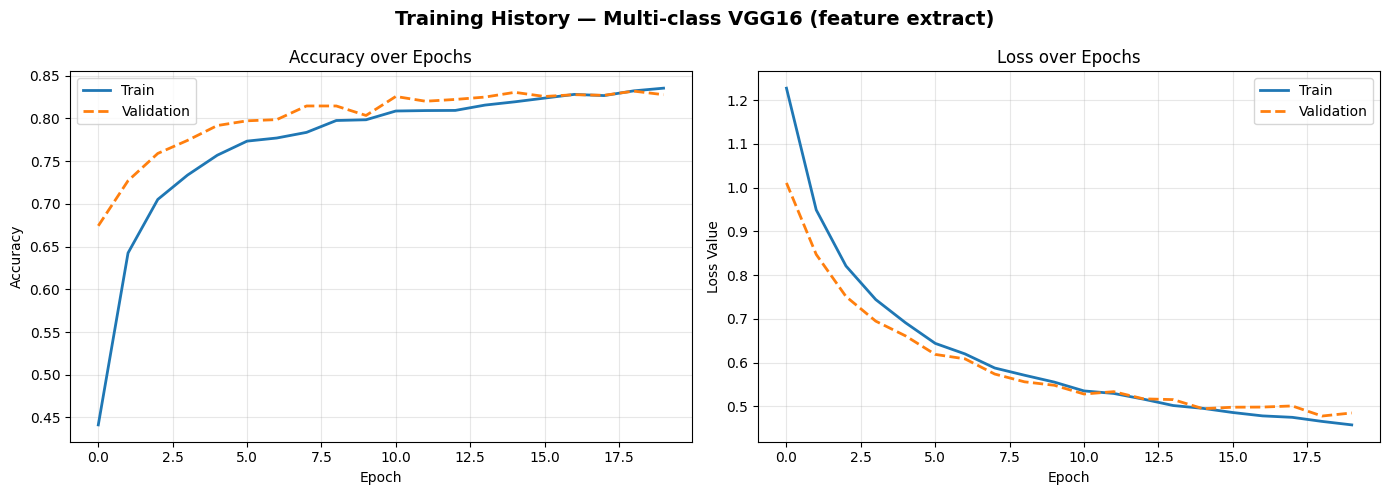


────────────────────────────────────────────────────────────
  VGG16 (feature extract)
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

     Healthy       0.89      0.95      0.92       360
      Glioma       0.89      0.73      0.80       360
  Meningioma       0.77      0.71      0.74       360
   Pituitary       0.79      0.94      0.86       360

    accuracy                           0.83      1440
   macro avg       0.83      0.83      0.83      1440
weighted avg       0.83      0.83      0.83      1440



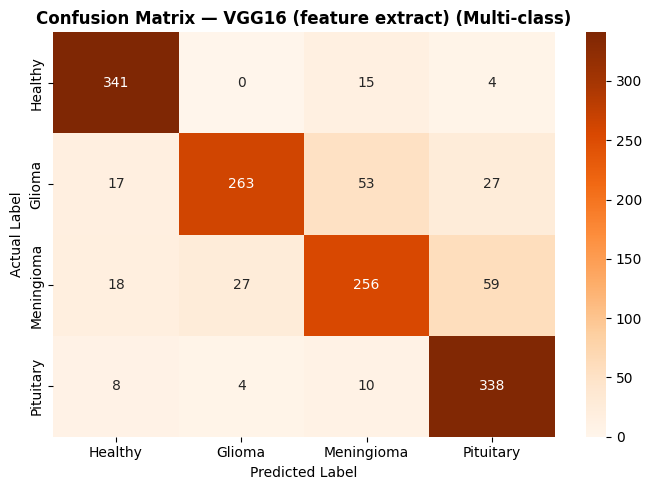

In [ ]:
# =============================================================================
# CELL 16 — Multi-Class Evaluation: Reports & Confusion Matrices
# =============================================================================
# For multi-class outputs we use np.argmax to convert the 4-probability softmax
# vector to a single predicted class integer (0–3).
# =============================================================================

multiclass_model_registry = [
    ('Custom CNN (from scratch)', mc_custom_cnn,  mc_custom_cnn_history,  'Blues'),
    ('ResNet50 (feature extract)', mc_resnet50,   mc_resnet50_history,    'Purples'),
    ('VGG16 (feature extract)',    mc_vgg16,       mc_vgg16_history,       'Oranges'),
]

for mc_model_name, mc_trained_model, mc_history, mc_cmap in multiclass_model_registry:

    plot_accuracy_and_loss(mc_history, model_name=f'Multi-class {mc_model_name}')

    # argmax converts softmax vector → integer class index
    mc_predicted_labels = np.argmax(
        mc_trained_model.predict(mc_val_images, verbose=0), axis=1
    )

    print(f"\n{'─'*60}")
    print(f"  {mc_model_name}")
    print(f"{'─'*60}")
    print(classification_report(mc_val_labels, mc_predicted_labels,
                                target_names=MULTICLASS_CLASS_NAMES))

    plot_confusion_matrix(
        true_labels=mc_val_labels,
        pred_labels=mc_predicted_labels,
        class_names=MULTICLASS_CLASS_NAMES,
        chart_title=f'Confusion Matrix — {mc_model_name} (Multi-class)',
        color_map=mc_cmap
    )


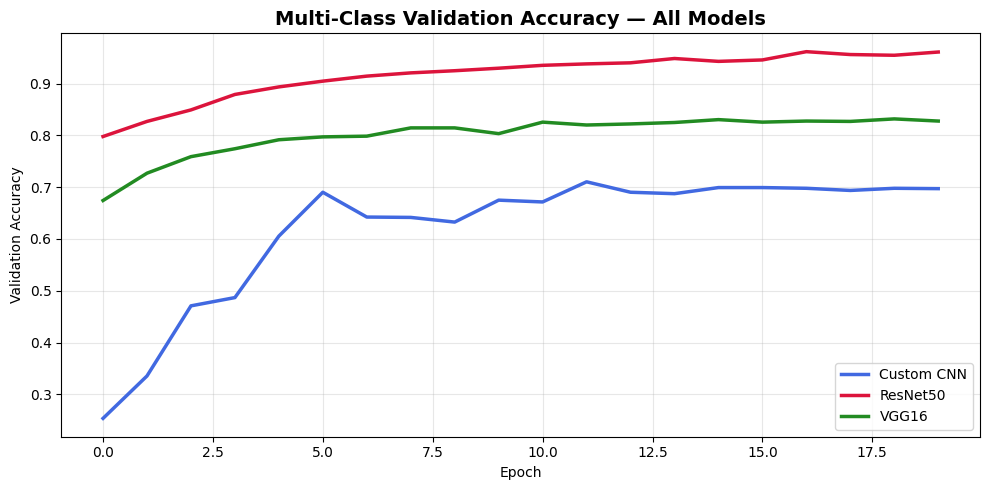


🏆 Multi-Class Classification — Final Comparison


,Model,Best Validation Accuracy (%),Best Validation Loss
0,ResNet50,96.18,0.1213
1,VGG16,83.19,0.4782
2,Custom CNN,71.04,0.7055


In [ ]:
# =============================================================================
# CELL 17 — Multi-Class Accuracy Comparison Chart & Summary Table
# =============================================================================

# Overlay all three val_accuracy curves on one chart for easy comparison
plt.figure(figsize=(10, 5))

multiclass_curve_styles = [
    (mc_custom_cnn_history, 'Custom CNN',  'royalblue'),
    (mc_resnet50_history,   'ResNet50',    'crimson'),
    (mc_vgg16_history,      'VGG16',       'forestgreen'),
]

for history_obj, curve_label, curve_color in multiclass_curve_styles:
    plt.plot(history_obj.history['val_accuracy'],
             label=curve_label, linewidth=2.5, color=curve_color)

plt.title('Multi-Class Validation Accuracy — All Models',
          fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Summary DataFrame
multiclass_results_dict = {
    'Model': ['Custom CNN', 'ResNet50', 'VGG16'],
    'Best Validation Accuracy (%)': [
        round(max(mc_custom_cnn_history.history['val_accuracy']) * 100, 2),
        round(max(mc_resnet50_history.history['val_accuracy'])   * 100, 2),
        round(max(mc_vgg16_history.history['val_accuracy'])      * 100, 2),
    ],
    'Best Validation Loss': [
        round(min(mc_custom_cnn_history.history['val_loss']), 4),
        round(min(mc_resnet50_history.history['val_loss']),   4),
        round(min(mc_vgg16_history.history['val_loss']),      4),
    ]
}

multiclass_results_df = pd.DataFrame(multiclass_results_dict)
multiclass_results_df = multiclass_results_df.sort_values('Best Validation Accuracy (%)',
                                                           ascending=False)
print("\n🏆 Multi-Class Classification — Final Comparison")
display(multiclass_results_df.reset_index(drop=True))


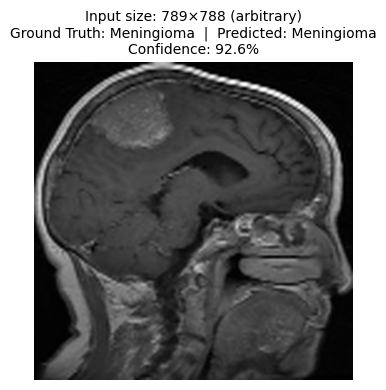

In [ ]:
# =============================================================================
# CELL 17b — Single-Image Prediction Demo (Multi-Class — ResNet50)
# =============================================================================
# Same idea as the binary demo earlier: predict_mri_scan() resizes any input
# image to what the model expects (128x128 here), so this works regardless
# of the original scan's resolution.
# =============================================================================

mc_demo_index      = random.randint(0, len(mc_val_images) - 1)
mc_demo_normalised = mc_val_images[mc_demo_index]
mc_ground_truth     = MULTICLASS_CLASS_NAMES[mc_val_labels[mc_demo_index]]

# Convert back to a raw uint8 BGR image, then resize to an arbitrary resolution
# to simulate an uploaded photo of unknown size
mc_demo_uint8    = (mc_demo_normalised * 255).astype(np.uint8)
random_mc_size   = (random.randint(150, 800), random.randint(150, 800))
mc_demo_resized  = cv2.resize(mc_demo_uint8, random_mc_size, interpolation=cv2.INTER_CUBIC)

mc_predicted_class, mc_prediction_confidence = predict_mri_scan(
    mc_demo_resized, mc_resnet50,
    target_size=MULTICLASS_IMG_SIZE,
    class_names=MULTICLASS_CLASS_NAMES,
    apply_crop=False   # already cropped once during dataset loading; avoid double-cropping
)

plt.figure(figsize=(4, 4))
plt.imshow(cv2.cvtColor(mc_demo_resized, cv2.COLOR_BGR2RGB))
plt.title(
    f"Input size: {random_mc_size[0]}×{random_mc_size[1]} (arbitrary)\n"
    f"Ground Truth: {mc_ground_truth}  |  Predicted: {mc_predicted_class}\n"
    f"Confidence: {mc_prediction_confidence:.1f}%",
    fontsize=10
)
plt.axis('off')
plt.tight_layout()
plt.show()


In [ ]:
# =============================================================================
# CELL 18 — Save All Trained Models to Disk
# =============================================================================
# Models are saved in the legacy HDF5 format (.h5) for broad compatibility.
# They can be reloaded with:  tf.keras.models.load_model('filename.h5')
# =============================================================================

models_to_save = [
    ('binary_vgg16.h5',          vgg16_classifier),
    ('binary_custom_cnn.h5',     custom_binary_cnn),
    ('binary_resnet50.h5',       resnet50_classifier),
    ('multiclass_custom_cnn.h5', mc_custom_cnn),
    ('multiclass_resnet50.h5',   mc_resnet50),
    ('multiclass_vgg16.h5',      mc_vgg16),
]

for save_filename, model_to_save in models_to_save:
    model_to_save.save(save_filename)
    print(f"✅ Saved: {save_filename}")

print("\n🎉 All models saved successfully.")


✅ Saved: binary_vgg16.h5
✅ Saved: binary_custom_cnn.h5


✅ Saved: binary_resnet50.h5
✅ Saved: multiclass_custom_cnn.h5


✅ Saved: multiclass_resnet50.h5
✅ Saved: multiclass_vgg16.h5

🎉 All models saved successfully.


In [ ]:
# =============================================================================
# CELL 19 — Upload All Trained Models to Hugging Face Hub
# =============================================================================
# Pushes all 6 saved .h5 files to a Hugging Face model repository so the
# Streamlit app can download them at runtime instead of bundling them locally.
#
# Requires a Hugging Face access token with WRITE permission:
#   https://huggingface.co/settings/tokens
# =============================================================================

!pip install -q huggingface_hub

from huggingface_hub import HfApi, login

# Paste your token here, or leave blank to be prompted securely
login()  # opens a prompt to paste your HF token (input is hidden)

HF_REPO_ID = "mvdu/brain-tumor-models"

api = HfApi()
api.create_repo(repo_id=HF_REPO_ID, repo_type="model", exist_ok=True)

for save_filename, _ in models_to_save:
    api.upload_file(
        path_or_fileobj=save_filename,
        path_in_repo=save_filename,
        repo_id=HF_REPO_ID,
        repo_type="model",
    )
    print(f"✅ Uploaded: {save_filename}")

print(f"\n🎉 All models uploaded to https://huggingface.co/{HF_REPO_ID}")


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

✅ Uploaded: binary_vgg16.h5


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

...

New Data Upload: |          |  0.00B /  0.00B            

✅ Uploaded: multiclass_resnet50.h5


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

✅ Uploaded: multiclass_vgg16.h5

🎉 All models uploaded to https://huggingface.co/mvdu/brain-tumor-models
